# Reading drums

In [138]:
import os
from pythonosc.udp_client import SimpleUDPClient
from pathlib import Path
from music21 import converter, note, chord
import time
import random

# from music21.note import Note, Unpitched
# from music21.stream import Part, Measure, Voice

In [3]:
ASSETS_ABSPATH = Path(os.environ.get("ASSETS_ABSPATH", "/assets"))
FILE_ABSPATH = ASSETS_ABSPATH / "MusicXML" / "Bland Drums.musicxml"

In [86]:
client = SimpleUDPClient(address="192.168.1.151", port=57121)

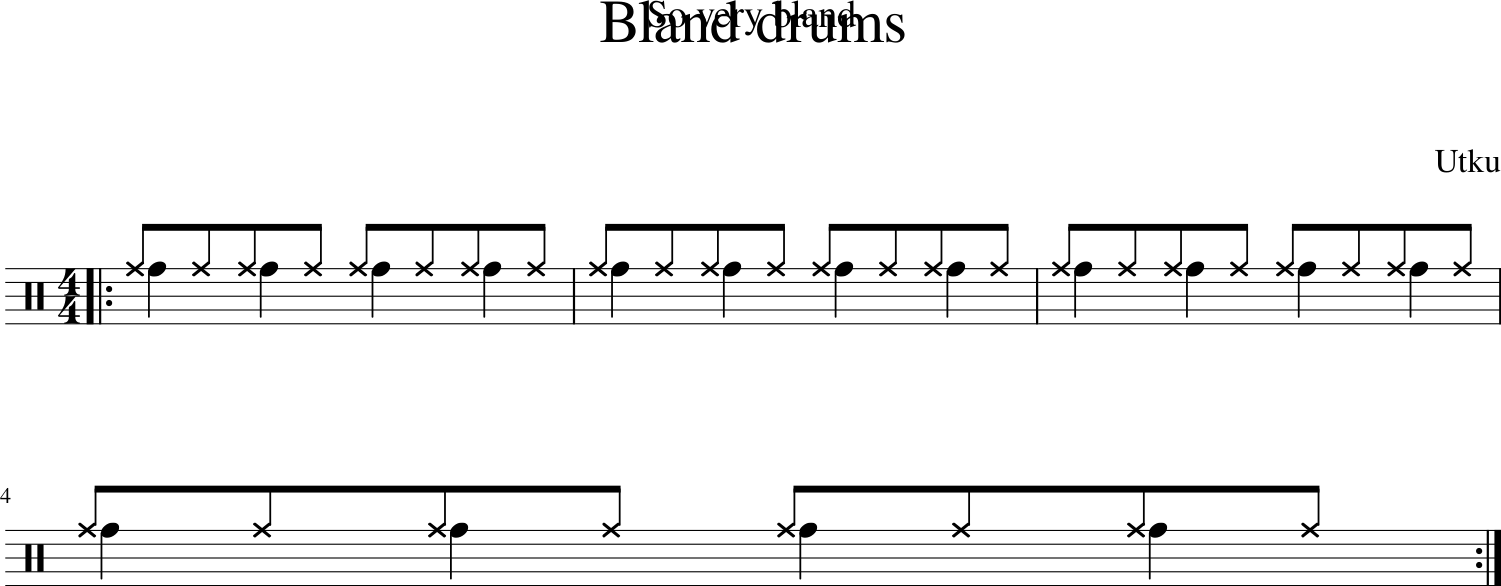

In [5]:
score = converter.parse(FILE_ABSPATH)
score.show()

In [ ]:
score.metronomeMarkBoundaries()

[(0.0, 16.0, <music21.tempo.MetronomeMark animato Quarter=120>)]

In [144]:
# Flatten it to get all notes and chords in one stream, sorted by offset
flat = score.flatten().notes
tempo = 120
# Group notes by their offset (i.e., start time)
from collections import defaultdict

notes_by_offset = defaultdict(list)
for n in flat:
    notes_by_offset[n.offset].append(n)

# Now stream them in time order
sorted_notes_by_offset = sorted(notes_by_offset.keys())
for _ in range(4):
    prev = -sorted_notes_by_offset[1]
    print(prev)
    for offset in sorted_notes_by_offset:
        notes = notes_by_offset[offset]
        # Send notes to SuperCollider (you can send them as a batch)
        print(f"At time {offset}:")
        for n in notes:
            if isinstance(n, note.Note):
                print(f"  Note: {n.pitch.name}, Duration: {n.quarterLength}")
            elif isinstance(n, note.Unpitched):
                print(n.displayName)
                match n.displayName:
                    # Kick
                    case "F4":
                        client.send_message("/drums", [36, 90])
                    # Ride
                    case "F5":
                        client.send_message("/drums", [53, 90])
                        # Tambourine
                        client.send_message("/drums", [3, 30])
                    # Ride crash
                    case "A5":
                        client.send_message("/drums", [59, 110])
                    # Snare
                    case "C5":
                        client.send_message("/drums", [38, 90])

            elif isinstance(n, chord.Chord):
                print(
                    f"  Chord: {[p.nameWithOctave for p in n.pitches]}, Duration: {n.quarterLength}"
                )
        time.sleep((offset - prev) * 60 / tempo)
        # time.sleep((offset - prev) * 60 / tempo + random.uniform(0, 0.02))
        prev = offset

-0.5
At time 0.0:
F5
F4
At time 0.5:
F5
At time 1.0:
F5
C5
At time 1.5:
F5
At time 2.0:
F5
F4
At time 2.5:
F5
At time 3.0:
F5
C5
At time 3.5:
F5
At time 4.0:
F5
F4
At time 4.5:
F5
At time 5.0:
F5
C5
At time 5.5:
F5
At time 6.0:
F5
F4
At time 6.5:
F5
At time 7.0:
F5
C5
At time 7.5:
F5
At time 8.0:
F5
F4
At time 8.5:
F5
At time 9.0:
F5
C5
At time 9.5:
F5
At time 10.0:
F5
F4
At time 10.5:
F5
At time 11.0:
F5
C5
At time 11.5:
F5
At time 12.0:
F5
F4
At time 12.5:
F5
At time 13.0:
F5
C5
At time 13.5:
F5
At time 14.0:
F5
F4
At time 14.5:
F5
At time 15.0:
F5
C5
At time 15.5:
A5
-0.5
At time 0.0:
F5
F4
At time 0.5:
F5
At time 1.0:
F5
C5
At time 1.5:
F5
At time 2.0:
F5
F4
At time 2.5:
F5
At time 3.0:
F5
C5
At time 3.5:
F5
At time 4.0:
F5
F4
At time 4.5:
F5
At time 5.0:
F5
C5
At time 5.5:
F5
At time 6.0:
F5
F4
At time 6.5:
F5
At time 7.0:
F5
C5
At time 7.5:
F5
At time 8.0:
F5
F4
At time 8.5:
F5
At time 9.0:
F5
C5
At time 9.5:
F5
At time 10.0:
F5
F4
At time 10.5:
F5
At time 11.0:
F5
C5
At time 11.

In [ ]:
for p in score.parts:
    for m in p.measures(1, None):
        if isinstance(m, Measure):
            for v in m:
                if isinstance(v, Voice):
                    for n in v.notes:
                        if isinstance(n, Unpitched):
                            match n.displayName:
                                case "F5":
                                    client.send_message("/drums", 36)
                                    print(36)
                                # print(n.displayName, v)
                            # print(n)
                    # print(v)
                # print(n)
            # print(m.recurse())

36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36


In [41]:
for r in score.recurse():
    if isinstance(r, note.Unpitched):
        n = note.Note(r.displayName)
        n = n.transpose(-29)
        print(n.pitch.midi, r.displayName)

48 F5
48 F5
48 F5
48 F5
48 F5
48 F5
48 F5
48 F5
36 F4
43 C5
36 F4
43 C5
48 F5
48 F5
48 F5
48 F5
48 F5
48 F5
48 F5
48 F5
36 F4
43 C5
36 F4
43 C5
48 F5
48 F5
48 F5
48 F5
48 F5
48 F5
48 F5
48 F5
36 F4
43 C5
36 F4
43 C5
48 F5
48 F5
48 F5
48 F5
48 F5
48 F5
48 F5
52 A5
36 F4
43 C5
36 F4
43 C5
